# Day 3 - Data Cleaning Topics

Welcome to the last day of the Intro to Python Bootcamp! You've learned a lot over the past couple days, starting with basic syntax and moving on to fully functional scripts that interact with external data. For this last day, we're going to take a look at some more practical topics and tasks that can be acheived with Python, including data cleaning, extraction, and visualiation. Then, you're going to be working on a short project where you will implement everyting you've learned.

## Learning Objectives

In this notebook, you will learn to:

- **Load and explore data** using Pandas DataFrames and exploratory data analysis (EDA) techniques
- **Identify data quality issues** including missing values, incorrect data types, duplicates, and inconsistent formatting
- **Handle missing data** strategically by choosing appropriate methods for different columns (filling, dropping, deriving from related fields)
- **Recognize and remove duplicate records** using composite keys (combinations of multiple fields) to identify true duplicates
- **Convert data types appropriately** to preserve data integrity (e.g., keeping leading zeros in ZIP codes by storing as strings)
- **Use Pandas methods** for practical data manipulation (`.fillna()`, `.astype()`, `.drop_duplicates()`, `.groupby()`, boolean indexing)
- **Apply domain knowledge** to make informed decisions about data cleaning strategies

### About This Dataset

You'll be working with a **realistic dataset intentionally containing common data quality issues**. This hands-on approach means you'll encounter the types of problems data professionals face daily:
- Missing values represented in multiple ways (NaN, -999 sentinel values)
- Inconsistent text formatting and typos
- Duplicate records
- Data type mismatches (numbers stored as text, text stored as numbers)

By the end of this lesson, you'll have cleaned this dataset and learned transferable skills applicable to any real-world data cleaning project.

## Examining Our Dataset
The data we will be working with for this session is a fictional dataset of registration survey responses for an upcoming health education workshop. Below are the details of the dataset:

### Data Dictionary: Workshop Participants Dataset
**Dataset Name:** `workshop_participants_east_coast.csv`  
**Description:** Contains registration profiles for 500 individuals signed up for an upcoming regional health education workshop. The dataset intentionally includes common real-world data anomalies to practice programmatic data cleaning, validation, and preparing geographic strings for geocoding.

### Table Schema Summary

| Column Name | Data Type (Raw) | Description | Expected Format / Valid Values | Known Data Quality Issues Included |
| :--- | :--- | :--- | :--- | :--- |
| **Participant_ID** | Integer | Unique identifier assigned sequentially to each workshop registration row. | `1001` to `1500` | None (used to track indexing and deduplication results). |
| **Name** | String / Object | Full name of the participant registration. | `[First Name] [Last Name]` | Contains structural duplicates (the same individual registered multiple times with identical data across columns). |
| **Age** | Float / Numeric | The self-reported age of the program participant. | Positive integers representing adult ages (`18` to `82`). | 1. Contains standard nulls (`NaN`).<br>2. Uses `-999` as a sentinel placeholder value for missing responses. |
| **Phone** | String / Object | Primary contact phone number for the registration. | 10-digit U.S. numbers. | 1. Inconsistent formats: mixed use of delimiters `(XXX) XXX-XXXX`, `XXX-XXX-XXXX`, and unformatted strings `XXXXXXXXXX`.<br>2. Missing entries (`NaN` and `-999`). |
| **Address** | String / Object | Street number and name provided for mailing or residence validation. | `[Street Number] [Street Name] [Suffix]` | Inconsistent suffix naming conventions (e.g., alternating between variations like `St`, `St.`, `Street`, `st`, `Rd`, or `Avenue`). |
| **City** | String / Object | The primary municipality name tied to the residence. | Standard Northeast/East Coast municipal names. | 1. Inconsistent typography or colloquialisms (e.g., `"Philly"` instead of `"Philadelphia"`).<br>2. Structural typos / spacing issues (e.g., `"NewYork"` instead of `"New York"`). |
| **State** | String / Object | Two-letter USPS postal abbreviation for the state code. | Standard US State codes (`NY`, `PA`, `NJ`, `MA`, etc.). | Uneven distributions (skewed intentionally with over 80% concentrated in `NY` and `PA`). |
| **Zip_Code** | Float / Numeric | The postal ZIP code corresponding to the physical address. | 5-digit string or numeric codes (e.g., starting with `100xx`, `191xx`). | 1. Truncated leading zeros due to automatic numeric parser detection (e.g., New England codes beginning with `0` reading incorrectly).<br>2. Missing values (`NaN`).<br>3. Sentinel placeholder values (`-999`). |
| **Workshop_Goal** | String / Object | Open-ended text response detailing what the user hopes to gain from the workshop. | Free-form character text strings. | 1. Inconsistent text casing and punctuation (e.g., `"get fit!"` vs `"To learn how to eat healthier"`).<br>2. Weak responses or raw flags representing a skipped question (e.g., `"N/A"`, `-999`, or `NaN`). |

## Session Setup

Before we begin working with data, we need to set up our environment by importing the necessary Python libraries. Each library provides specific functionality that we'll use throughout this lesson:

- **Pandas (`pd`)**: Our primary tool for data manipulation and cleaning. It provides DataFrames (tabular data structures) and methods for filtering, transforming, and analyzing data.
- **NumPy (`np`)**: Fundamental library for numerical computing. We'll use it for mathematical operations and handling special values like NaN (Not a Number).
- **Matplotlib**: Library for creating visualizations and plots to help us understand data patterns.
- **GeoPy**: Tools for geocoding (converting addresses to geographic coordinates), which we may use later for geographic analysis.

Run the following cell to import these modules into your notebook environment.

If you are working in your own environment or encounter module import errors, make sure you have installed all required dependencies. You can install them using:

```bash
pip install -r requirements.txt
```

> **Pro-tip**: You can also run bash commands directly from within your notebook by prefixing a command with `!`. For example:
>
> `!pip install -r requirements.txt`
>
> This is useful for installing packages on-the-fly without leaving your notebook environment.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopy

survey_data = pd.read_csv("data/workshop_participants_east_coast.csv")

survey_data.head()

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal
0,1001,Jacob Taylor,53.0,(280) 635-2449,710 Broadway Rd,Portland,ME,4184.0,To understand nutrition labels
1,1002,Jacob Brown,58.0,(583) 256-8770,452 Oak St,Buffalo,NY,14257.0,get fit!
2,1003,Mason Thomas,26.0,(203) 493-8898,351 Hill Road,Albany,NY,12290.0,Want to lower my blood pressure.
3,1004,Michael Gonzalez,43.0,7582841440,458 Broadway Rd.,Buffalo,NY,14218.0,I want to start cooking more at home.
4,1005,Mason Miller,27.0,9305552438,736 Washington Road,Albany,NY,12247.0,To understand nutrition labels


## Using Exploratory Data Analysis to Find Data Quality Issues

### Leveraging Data Exploration Tools

Before diving into data cleaning, we need to understand the structure and content of our dataset. In this section, we've imported the CSV file containing workshop participant registration data into a Pandas DataFrame. This gives us a structured, tabular format that allows us to easily analyze and manipulate the data using Python.

The first thing we're going to do is generate some basic info about our dataframe using the `.info()` method. If we didn't have the data dictionary provided above, we could still use this method to give us some inital facts about the number of rows, columns, and datatypes of those columns:

In [5]:
survey_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Participant_ID  500 non-null    int64  
 1   Name            500 non-null    str    
 2   Age             485 non-null    float64
 3   Phone           445 non-null    str    
 4   Address         500 non-null    str    
 5   City            500 non-null    str    
 6   State           500 non-null    str    
 7   Zip_Code        453 non-null    float64
 8   Workshop_Goal   407 non-null    str    
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


### Exploring Dataset Metrics

The `.info()` method provides a great high-level overview, but sometimes we need to dig deeper into specific aspects of our data. Below are some methods for extracting individual pieces of information from your DataFrame that can help with analysis and troubleshooting:

- **`.shape`** - Returns the dimensions (number of rows, number of columns) as a tuple
- **`.columns`** - Shows the names of all columns
- **`.dtypes`** - Displays the data type of each column
- **`.isnull().sum()`** - Counts missing values per column
- **`.describe()`** - Generates summary statistics for numeric columns

In [14]:
print("Number of rows and columns in the dataset:")
print(survey_data.shape) # get rows and columns
print("===========================================")

print("Column names in the dataset:")
print(survey_data.columns) # get column names
print("===========================================")

print("Data types of columns in the dataset:")
print(survey_data.dtypes) # get data types of columns
print("===========================================")

print("Number of missing values in each column:")
print(survey_data.isnull().sum()) # get number of missing values in each column
print("===========================================")


print("Summary statistics for numeric columns in the dataset:")
print(survey_data.describe()) # get summary statistics for numeric columns
print("===========================================")

Number of rows and columns in the dataset:
(500, 9)
Column names in the dataset:
Index(['Participant_ID', 'Name', 'Age', 'Phone', 'Address', 'City', 'State',
       'Zip_Code', 'Workshop_Goal'],
      dtype='str')
Data types of columns in the dataset:
Participant_ID      int64
Name                  str
Age               float64
Phone                 str
Address               str
City                  str
State                 str
Zip_Code          float64
Workshop_Goal         str
dtype: object
Number of missing values in each column:
Participant_ID     0
Name               0
Age               15
Phone             55
Address            0
City               0
State              0
Zip_Code          47
Workshop_Goal     93
dtype: int64
Summary statistics for numeric columns in the dataset:
       Participant_ID         Age      Zip_Code
count      500.000000  485.000000    453.000000
mean      1250.500000  -27.243299  13169.269316
std        144.481833  276.019071   5490.613177
min       

## Discussion
Take a look at the summary statistics and the datatype tables. What are some things you notice about the calculations? How might we fix them?

### A note about DataTypes in Pandas
In Pandas, data types (or "dtypes") determine how data is stored in memory and what operations can be performed on it. The most common types include:

- **int64**: Integer numbers (whole numbers with no decimal point)
- **float64**: Floating-point numbers (numbers with decimals)
- **object**: Typically used for text strings, but can hold any Python object; this is the default for mixed data types
- **bool**: Boolean values (True or False)
- **datetime64**: Date and time values

Choosing the correct data type is important because it affects:
1. **Memory usage**: Integer types use less memory than float types, which use less than object types
2. **Operations available**: Some operations only work on specific types (e.g., you can't average text strings)
3. **Data integrity**: Storing phone numbers or IDs as integers can lose leading zeros (e.g., "04184" becomes 4184)

In our dataset, we notice that Participant_ID and Zip_Code are stored as numeric types, but they should be strings to preserve leading zeros and prevent unwanted mathematical operations.

### Converting Data Types

Now that we've identified the data quality issues, let's start cleaning. One of the first steps is to fix the data types for columns where the current type doesn't match the data's purpose:

- **`Participant_ID`**: Should be a string (not a number) because IDs are identifiers, not values to calculate with
- **`Zip_Code`**: Should be a string to preserve leading zeros (e.g., "04184" should not become "4184")
- **`Age`**: Should be an integer (whole number) rather than float, since ages are whole numbers and the decimal values are artifacts of our missing data handling

We'll also need to handle the sentinel value `-999` that represents missing age data. The `.fillna()` method allows us to replace `NaN` (missing) values, and `.astype()` converts between data types.

In [28]:
fixed_dtypes = survey_data.fillna(0).astype({
    'Age': 'int64',
    'Participant_ID': 'str',
    'Zip_Code': 'str',
})

print(fixed_dtypes.dtypes) # check data types after conversion

display(fixed_dtypes.head())

print("Summary statistics for numeric columns after conversion:")
print(fixed_dtypes.describe()) # get summary statistics for numeric columns after conversion

Participant_ID       str
Name                 str
Age                int64
Phone             object
Address              str
City                 str
State                str
Zip_Code             str
Workshop_Goal     object
dtype: object


,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,4184.0,To understand nutrition labels
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257.0,get fit!
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290.0,Want to lower my blood pressure.
3,1004,Michael Gonzalez,43,7582841440,458 Broadway Rd.,Buffalo,NY,14218.0,I want to start cooking more at home.
4,1005,Mason Miller,27,9305552438,736 Washington Road,Albany,NY,12247.0,To understand nutrition labels


Summary statistics for numeric columns after conversion:
              Age
count  500.000000
mean   -26.426000
std    271.878636
min   -999.000000
25%     29.000000
50%     47.000000
75%     65.250000
max     82.000000


Now we can see age is the only numeric column being calculated in the summary stats. The string conversion on `Zip_Code` still preserved the `.0` decimal place at the end, but we'll take care of that in the "String Functions" section.

## Data Issue #1: Missing Values

In [31]:
survey_data.isnull().sum().sort_values(ascending=False) # get number of missing values in each column sorted in descending order

Workshop_Goal     93
Phone             55
Zip_Code          47
Age               15
Participant_ID     0
Address            0
Name               0
State              0
City               0
dtype: int64

### Understanding Missing Data

Missing data is one of the most common data quality issues in real-world datasets. It can occur due to various reasons: incomplete form submissions, system errors, non-applicable responses, or intentional redactions. Before we can proceed with analysis, we need to decide how to handle these missing values.

There are several strategies for dealing with missing data, each with different trade-offs:

| Strategy | Pros | Cons |
|:---|:---|:---|
| **Fill with a constant (0 or "NA")** | Simple to implement | Skews statistical analysis; not realistic |
| **Drop rows with missing values** | Removes ambiguity | Can lose significant amounts of data |
| **Forward/backward fill** | Preserves temporal patterns | Only works if data has logical ordering |
| **Fill with mean/median** | More statistically sound | Still skews overall trends; inappropriate for categorical data |
| **Use domain knowledge** | Most realistic; prevents bias | Labor-intensive; requires expertise |

The best approach depends on:
1. **How much data is missing** (5% vs 50%?)
2. **Why it's missing** (random or systematic pattern?)
3. **What column it is** (critical identifier vs optional text?)
4. **Your analysis goals** (descriptive statistics vs machine learning?)

In this dataset, we'll use a mixed approach based on the column's importance:

In [50]:
survey_data = survey_data.replace(-999, np.nan).fillna({ # replace -999 with NaN and fill NaN values with appropriate values
    'Age': survey_data['Age'].median(),
    'Phone': 'None',
    'Zip_Code': 'Unknown',
    'Workshop_Goal': 'None',
}).astype({
    'Age': 'int64',
    'Participant_ID': 'str',
    'Zip_Code': 'str',
})

survey_data.head(25) # display first 25 rows of the cleaned dataset

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,4184.0,To understand nutrition labels
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257.0,get fit!
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290.0,Want to lower my blood pressure.
3,1004,Michael Gonzalez,43,7582841440,458 Broadway Rd.,Buffalo,NY,14218.0,I want to start cooking more at home.
4,1005,Mason Miller,27,9305552438,736 Washington Road,Albany,NY,12247.0,To understand nutrition labels
5,1006,Mia Lopez,82,483-155-2038,523 Washington ave,Harrisburg,PA,17170.0,healthy lifestyle
6,1007,Sofia Anderson,20,None,425 Maple Ave,New York,NY,10076.0,None
7,1008,Mason Garcia,55,209-405-2758,920 Elm ave,Buffalo,NY,14269.0,To understand nutrition labels
8,1009,Emma Johnson,49,7783102124,842 Cedar Rd.,Rochester,NY,14628.0,None
9,1010,Mason Johnson,80,(315) 966-3425,899 Washington St.,Brooklyn,NY,11231.0,healthy lifestyle


## Data Issue #2: Duplicate Values

In [34]:
for col in survey_data.columns:
    print(f"Column: {col}")
    print(survey_data[col].value_counts())
    print("===========================================")

Column: Participant_ID
Participant_ID
1001    1
1002    1
1003    1
1004    1
1005    1
       ..
1496    1
1497    1
1498    1
1499    1
1500    1
Name: count, Length: 500, dtype: int64
Column: Name
Name
Evelyn Davis          5
Jacob Moore           5
Evelyn Rodriguez      5
Olivia Johnson        4
Ethan Jones           4
                     ..
Avery Martinez        1
James Johnson         1
Henry Davis           1
Charlotte Gonzalez    1
Charlotte Davis       1
Name: count, Length: 318, dtype: int64
Column: Age
Age
-999    36
 49     26
 54     15
 38     14
 80     13
        ..
 39      4
 22      3
 61      3
 65      2
 30      2
Name: count, Length: 66, dtype: int64
Column: Phone
Phone
None              55
-999              35
(583) 256-8770     2
340-139-5700       2
675-776-5151       2
                  ..
5815692391         1
(310) 602-8267     1
(716) 800-7877     1
9219235641         1
5754707272         1
Name: count, Length: 395, dtype: int64
Column: Address
Address
452

### Identifying Duplicate Registrations

Duplicate entries are another common data quality issue. They can occur when:
- The same person registers multiple times (accidental double-registration)
- Data is merged from multiple sources without deduplication
- Test records are left in production datasets

In our dataset, the high frequency of certain names may indicate duplicate registrations. While common names, cities, and states are expected in any dataset, and even duplicate addresses can occur (e.g., apartment buildings), repeatedly seeing the exact same name suggests potential duplicates.

However, simply filtering by name is insufficient. After all, there can legitimately be multiple people with the same name. We need to combine multiple columns to identify likely duplicates:

**Our approach:**
1. Look at name frequencies to spot potential duplicates
2. Combine Name with other fields (Age, Phone) to create a "composite key"
3. Find rows where this composite key is identical
4. Examine the full records to decide if they're true duplicates
5. Remove duplicates while keeping the first occurrence

Let's investigate by filtering for rows where the Name equals "Evelyn Davis" to see if the other information matches:

In [63]:
survey_data["Name"] == "Evelyn Davis"

0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Name: Name, Length: 500, dtype: bool

When you write `survey_data["Name"] == "Evelyn Davis"`:

- `survey_data["Name"]` selects the `Name` column from the DataFrame.
- That selection is a pandas `Series` — a one-dimensional labeled array with the same row index as the DataFrame.
- The `== "Evelyn Davis"` comparison is applied elementwise to the Series.
- The result is another Series of boolean values (`True` or `False`), one for each row.
- Each `True` means that row has `Name` equal to `"Evelyn Davis"`; each `False` means it does not.

So the code produces a boolean mask Series, not a filtered DataFrame. If you want the matching rows, you would use that mask to index `survey_data`, for example:

In [65]:
survey_data[survey_data["Name"] == "Evelyn Davis"]

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal
58,1059,Evelyn Davis,27,234-401-1328,360 Elm St,Brooklyn,NY,11230.0,Want to lower my blood pressure.
117,1118,Evelyn Davis,61,904-817-2560,689 Cedar Avenue,Burlington,VT,5481.0,None
153,1154,Evelyn Davis,23,629-773-9565,254 Elm Street,Albany,NY,12295.0,To understand nutrition labels
260,1261,Evelyn Davis,52,(768) 542-7240,494 Pine Rd.,Brooklyn,NY,11273.0,get fit!
269,1270,Evelyn Davis,46,253-202-7771,15 Broadway St.,Boston,MA,2130.0,I want to start cooking more at home.


### Analysis: Are These Duplicates?

Looking at the results above, we can see that all the "Evelyn Davis" records have **different values** in almost every other column:
- Different ages (27, 61, 23, 52, 46)
- Different phone numbers
- Different addresses and cities
- Different workshop goals

This suggests these are actually **different people** who happen to share the same name—not duplicates. So simply filtering by name is not a reliable deduplication strategy.

### Finding a Unique Identifier

To reliably identify true duplicates, we need to find a combination of fields that would uniquely identify a person. Some possible strategies:

| Approach | Pros | Cons |
|:---|:---|:---|
| Name only | Simple | Too many false positives (common names) |
| Name + Age | More specific | Still might have collisions |
| Name + Age + Phone | Very specific | Might miss duplicates if phone differs |
| Participant_ID | Guaranteed unique | Can't be used; IDs are always unique by design |

For this dataset, we'll use **Name + Age + Phone** as our composite key. While there's a small chance this could miss some duplicates (e.g., if someone registered with and without a phone number), it's a good balance between specificity and practicality. The likelihood of the same person registering twice with identical name, age, AND phone number in a sample of 500 is relatively low.

In [69]:
survey_data.groupby(["Name", "Age"]).size().reset_index(name='Count').sort_values(by='Count', ascending=False)

,Name,Age,Count
218,Evelyn Rodriguez,49,4
444,Olivia Miller,70,2
163,Emily Jackson,39,2
56,Ava Hernandez,68,2
212,Evelyn Jones,66,2
...,...,...,...
18,Abigail Taylor,71,1
19,Abigail Thomas,33,1
20,Abigail Thomas,54,1
21,Abigail Williams,54,1


### Grouping by Multiple Columns

Now that we've established that Name alone is insufficient for identifying duplicates, let's combine Name with Age and check how many times each combination appears. The `.groupby()` method groups rows by one or more columns and allows us to count occurrences within each group.

Looking at the output:
- **Evelyn Rodriguez, age 49** appears 4 times (most frequent Name+Age combo)
- Several other combinations appear 2 times
- Most combinations appear only once

Let's examine the top duplicate candidate (Evelyn Rodriguez, 49) more closely to see if these are true duplicates or just coincidences:

In [ ]:
mask = None

survey_data[mask]


,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal
137,1138,Evelyn Rodriguez,49,553-846-6139,404 Hill Rd,Trenton,NJ,8615.0,None
210,1211,Evelyn Rodriguez,49,358-140-3518,512 Hill Street,Trenton,NJ,8619.0,improve overall health
346,1347,Evelyn Rodriguez,49,358-140-3518,512 Hill Street,Trenton,NJ,8619.0,improve overall health
404,1405,Evelyn Rodriguez,49,553-846-6139,404 Hill Rd,Trenton,NJ,8615.0,None


## Even though we have 4 people with the same name and age, we have two sets of different phone numbers and addresses. From this data, do you still think it's the same Evelyn Rodgriguez?

- the combination of name, age, and city/state could suggest that it is still the same person
- different phone number and address could signal a recent move since the time they first registered for the workshop (phone number is likely for a home phone)
- think of the data source: online survey or registration tool could have taken their location and coded 2 different addresses
- Likely the same person, but we still have duplicate entries based on the two addresses
- We are forced to make an assumption in this case (name + age + phone gives you the unique person), but it will result in Evelyn still showing up on the list twice. This is where some manual work during or after the workshop will have to be done (There is still the possibility of these actually being two separate people!)

Let's look at the duplicated rows based on this criteria

In [ ]:
mask = survey_data.duplicated(subset=["Name", "Age", "Phone"], keep=False)

survey_data[mask]

# survey_data[mask]\
#     .groupby(["Name", "Age", "Phone"])\
#     .size()\
#     .reset_index(name='Count')\
#     .sort_values(by='Count', ascending=False)

### Removing Duplicate Records

Now that we've identified our deduplication strategy—treating Name, Age, and Phone as a composite unique identifier—we can use the `.drop_duplicates()` method to remove duplicate records.

The `.drop_duplicates()` method has two important parameters:
- **`subset`**: Which columns to check for duplicates (we specify Name, Age, Phone)
- **`keep`**: Which copy to keep when duplicates are found:
  - `'first'` - keeps the first occurrence (most common)
  - `'last'` - keeps the last occurrence
  - `False` - removes all occurrences of duplicates

After deduplication, we'll verify our results by grouping by the same columns to ensure there are no more duplicates (each count should be 1).

In [90]:
duplicate_criteria = ["Name", "Age", "Phone"]

survey_data = survey_data.drop_duplicates(subset=duplicate_criteria, keep='first', inplace=False)

survey_data\
    .groupby(duplicate_criteria)\
    .size()\
    .reset_index(name='Count')\
    .sort_values(by='Count', ascending=False)

,Name,Age,Phone,Count
0,Abigail Anderson,35,None,1
1,Abigail Brown,49,4282422679,1
2,Abigail Davis,42,None,1
3,Abigail Davis,62,3054929246,1
4,Abigail Garcia,78,369-176-9055,1
...,...,...,...,...
475,Sophia Moore,51,8378473315,1
476,Sophia Moore,75,2068773615,1
477,Sophia Rodriguez,38,(899) 356-3399,1
478,Sophia Williams,70,9763468800,1


## Data Issue #3: Text Formatting and Invalid Values

In [114]:
survey_data["Zip_Code"] = survey_data["Zip_Code"].str.replace('.0', '').str.zfill(5) # pad Zip_Code with leading zeros to ensure 5 digits

survey_data.head()

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,04184,To understand nutrition labels
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257,get fit!
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290,Want to lower my blood pressure.
3,1004,Michael Gonzalez,43,7582841440,458 Broadway Rd.,Buffalo,NY,14218,I want to start cooking more at home.
4,1005,Mason Miller,27,9305552438,736 Washington Road,Albany,NY,12247,To understand nutrition labels


## splitting the name columns into first and last

In [129]:
print("Simple split of the 'Name' column:")
print(survey_data['Name'].str.split())
print("============================================")

print("Split of the 'Name' column with expand=True:")
print(survey_data['Name'].str.split(expand=True))
print("============================================")

print("Split of the 'Name' column with expand=True and renamed columns:")
print(survey_data['Name'].str.split(expand=True).rename(columns={0: 'First_Name', 1: 'Last_Name'}))
print("============================================")

print("Split of the `Name` column into separate parts using lambda functions:")
print(
    survey_data['Name'].str.split().apply(lambda x: x[0]).rename("First_Name"),
    survey_data['Name'].str.split().apply(lambda x: x[1]).rename("Last_Name")
)


Simple split of the 'Name' column:
0            [Jacob, Taylor]
1             [Jacob, Brown]
2            [Mason, Thomas]
3        [Michael, Gonzalez]
4            [Mason, Miller]
               ...          
495           [Ethan, Jones]
496    [Charlotte, Gonzalez]
497           [Noah, Miller]
498       [Charlotte, Davis]
499        [Amelia, Johnson]
Name: Name, Length: 480, dtype: object
Split of the 'Name' column with expand=True:
             0         1
0        Jacob    Taylor
1        Jacob     Brown
2        Mason    Thomas
3      Michael  Gonzalez
4        Mason    Miller
..         ...       ...
495      Ethan     Jones
496  Charlotte  Gonzalez
497       Noah    Miller
498  Charlotte     Davis
499     Amelia   Johnson

[480 rows x 2 columns]
Split of the 'Name' column with expand=True and renamed columns:
    First_Name Last_Name
0        Jacob    Taylor
1        Jacob     Brown
2        Mason    Thomas
3      Michael  Gonzalez
4        Mason    Miller
..         ...       ..

how we will do it today:

In [131]:
survey_data[['First_Name', 'Last_Name']] = survey_data['Name'].str.split(expand=True).rename(columns={0: 'First_Name', 1: 'Last_Name'})
survey_data.head()

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal,First_Name,Last_Name
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,04184,To understand nutrition labels,Jacob,Taylor
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257,get fit!,Jacob,Brown
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290,Want to lower my blood pressure.,Mason,Thomas
3,1004,Michael Gonzalez,43,7582841440,458 Broadway Rd.,Buffalo,NY,14218,I want to start cooking more at home.,Michael,Gonzalez
4,1005,Mason Miller,27,9305552438,736 Washington Road,Albany,NY,12247,To understand nutrition labels,Mason,Miller


other way to do it by joining

In [138]:
name_parts = survey_data['Name'].str.split(expand=True)

survey_data.merge(name_parts, on=survey_data.index, how='left')

survey_data.merge(name_parts.rename(columns={0: 'First_Name', 1: 'Last_Name'}), left_index=True, right_index=True, how='left', suffixes=('', '_new'))

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal,First_Name,Last_Name,First_Name_new,Last_Name_new
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,04184,To understand nutrition labels,Jacob,Taylor,Jacob,Taylor
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257,get fit!,Jacob,Brown,Jacob,Brown
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290,Want to lower my blood pressure.,Mason,Thomas,Mason,Thomas
3,1004,Michael Gonzalez,43,7582841440,458 Broadway Rd.,Buffalo,NY,14218,I want to start cooking more at home.,Michael,Gonzalez,Michael,Gonzalez
4,1005,Mason Miller,27,9305552438,736 Washington Road,Albany,NY,12247,To understand nutrition labels,Mason,Miller,Mason,Miller
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1496,Ethan Jones,29,None,548 Main rd,Harrisburg,PA,17183,Want to lower my blood pressure.,Ethan,Jones,Ethan,Jones
496,1497,Charlotte Gonzalez,20,(716) 800-7877,497 Hill St.,Washington,DC,20078,healthy lifestyle,Charlotte,Gonzalez,Charlotte,Gonzalez
497,1498,Noah Miller,58,9219235641,328 Cedar St,Washington,DC,20079,None,Noah,Miller,Noah,Miller
498,1499,Charlotte Davis,45,-999,460 Pine Street,Harrisburg,PA,17185,To learn how to eat healthier,Charlotte,Davis,Charlotte,Davis


In [121]:
survey_data['Name'].str.split(expand=True)
survey_data['Name'].str.split(expand=True).rename(columns={0: 'First_Name', 1: 'Last_Name'})
survey_data[['First_Name', 'Last_Name']] = survey_data['Name'].str.split(expand=True).rename(columns={0: 'First_Name', 1: 'Last_Name'})
survey_data['Name'].str.split().apply(lambda x: x[0])

0          Jacob
1          Jacob
2          Mason
3        Michael
4          Mason
         ...    
495        Ethan
496    Charlotte
497         Noah
498    Charlotte
499       Amelia
Name: Name, Length: 480, dtype: str

cleaning phone number:
- convert all phone numbers to numbers only, then format in phone number format

In [ ]:
survey_data["Phone"].value_counts()

Phone
None              53
-999              34
(280) 635-2449     1
(583) 256-8770     1
(203) 493-8898     1
                  ..
5815692391         1
(310) 602-8267     1
(716) 800-7877     1
9219235641         1
5754707272         1
Name: count, Length: 395, dtype: int64

In [145]:
survey_data['Phone'] = survey_data['Phone']\
.str.replace("-999", "None")\
.str.replace(r'\D', '', regex=True)\
.apply(lambda x: f"({x[:3]}) {x[3:6]}-{x[6:]}" if len(x) == 10 else x) # format Phone numbers to (XXX) XXX-XXXX if they have 10 digits

survey_data.head()

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal,First_Name,Last_Name
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,04184,To understand nutrition labels,Jacob,Taylor
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257,get fit!,Jacob,Brown
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290,Want to lower my blood pressure.,Mason,Thomas
3,1004,Michael Gonzalez,43,(758) 284-1440,458 Broadway Rd.,Buffalo,NY,14218,I want to start cooking more at home.,Michael,Gonzalez
4,1005,Mason Miller,27,(930) 555-2438,736 Washington Road,Albany,NY,12247,To understand nutrition labels,Mason,Miller


In [146]:
survey_data["Workshop_Goal"].value_counts()

Workshop_Goal
None                                     85
I want to start cooking more at home.    47
improve overall health                   47
healthy lifestyle                        45
Want to lower my blood pressure.         44
my doctor recommended this class         43
To understand nutrition labels           40
get fit!                                 40
lose weight and eat better               35
To learn how to eat healthier            33
-999                                     21
Name: count, dtype: int64

<Axes: title={'center': 'Workshop Goals Distribution'}, xlabel='Count', ylabel='Workshop Goal'>

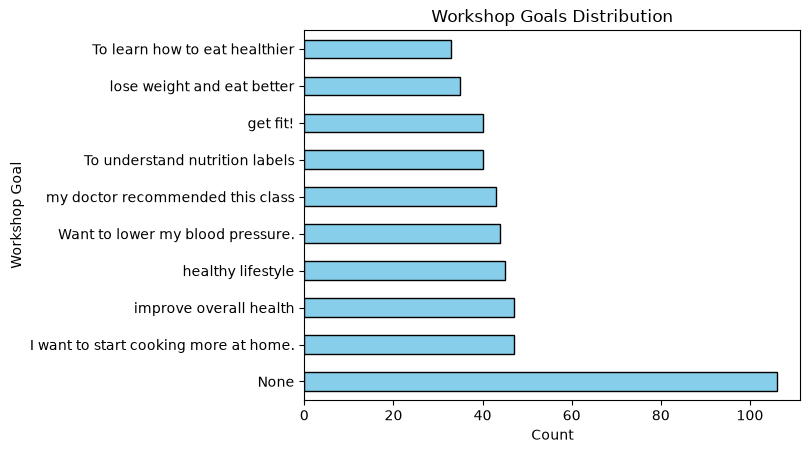

In [ ]:
survey_data["Workshop_Goal"] = survey_data["Workshop_Goal"].replace("-999", "None")
survey_data["Workshop_Goal"]\
.value_counts()\
.plot(kind='barh', title='Workshop Goals Distribution', ylabel='Workshop Goal', xlabel='Count', color='skyblue', edgecolor='black')

## Integrating additional datasets and filetypes

Pandas has the capability to read in multtiple different filetypes, including excel workbooks. In the following example, we have an additional list of workshop participants that we received from a different source, and our task is to integrate it with our existing list. There is a possibility for some overlap between the two lists, so we're going to need to account for any duplicates.

In [164]:
df2 = pd.read_excel("data/workshop_participants_secondary.xlsx")

pd.concat([survey_data, df2], ignore_index=True)

,Participant_ID,Name,Age,Phone,Address,City,State,Zip_Code,Workshop_Goal,First_Name,Last_Name
0,1001,Jacob Taylor,53,(280) 635-2449,710 Broadway Rd,Portland,ME,04184,To understand nutrition labels,Jacob,Taylor
1,1002,Jacob Brown,58,(583) 256-8770,452 Oak St,Buffalo,NY,14257,get fit!,Jacob,Brown
2,1003,Mason Thomas,26,(203) 493-8898,351 Hill Road,Albany,NY,12290,Want to lower my blood pressure.,Mason,Thomas
3,1004,Michael Gonzalez,43,(758) 284-1440,458 Broadway Rd.,Buffalo,NY,14218,I want to start cooking more at home.,Michael,Gonzalez
4,1005,Mason Miller,27,(930) 555-2438,736 Washington Road,Albany,NY,12247,To understand nutrition labels,Mason,Miller
...,...,...,...,...,...,...,...,...,...,...,...
625,2146,Sandra White,36,840-903-3131,219 Walnut Road,Philadelphia,PA,19146.0,Get active,NaN,NaN
626,2147,Nancy Walker,62,(330) 822-5580,929 Lake Avenue,Philly,PA,19146.0,Doctor told me to come,NaN,NaN
627,2148,Sandra Harris,60,879-496-8597,375 View Road,Brooklyn,NY,11278.0,Learn to cook healthy meals,NaN,NaN
628,2149,Donna Clark,57,637-150-1198,22 Broadway Street,Pittsburgh,PA,15277.0,Doctor told me to come,NaN,NaN


## Extracting Data From PDF files with `pdfplumber`

Extracting data from PDF files can be tricky depending on their quality and source of the information. While some are completely digitally generated, which makes the text fully capable of being scanned and copied, others can be a converted image or scan of a page that makes any type of copying of the text impossible. In the case of the second situation, different technologies like OCR (Optical Character Recognition) may be deployed to extract certain visual elements from files.

In this next section, we will look the the PDFPlumber pakage in order to extract data from a pdf file. On your computer or in your browser, open the `data/pdf/afr_contact_list.pdf` practice file. We're going to create our dataset from the first 3 columns of this table. You're notice that the values in the second column contain multiple invividual's contact information, we're only going to take the first one in each row and designate them as the primary coordinator.

Using a context manager to connect to the pdf, we can get a list of all of the pages contained in the file.


In [ ]:
import pdfplumber as pdp

file_path = 'data/pdf/afr_contact_list.pdf'
with pdp.open(file_path) as pdf:
    print(pdf.pages)

[<Page:1>, <Page:2>, <Page:3>, <Page:4>]
4


Each item in this list is a special object created by `pdfplumber` that represents that particular page of the document. This object comes with several methods that can extract the content frpm the page in several formas according to your needs:
- `page.extract_text()` - Extracts all text, preserving line breaks, spacing, and other formatting
- `page.extract_words()` - Extracts the exact locations of every character, word, and shape
- `page.extract_table()`/`page.extract_tables()` - Extracts tables as a nested list of rows that can easily be converted into a pandas dataframe.
- `page.images` - Returns a list of the images found on the page.

We're going to use the `.extract_table()` method because there is only one table on each page. Here is the core workflow:

In [48]:
rows = []

file_path = 'data/pdf/afr_contact_list.pdf'
with pdp.open(file_path) as pdf:
    for page in pdf.pages:
        table = page.extract_table()
        if table:
            rows.extend(table[1:]) #exclude header row

rows

[['Benin',
  'John Borrazzo\n(202-712-4816)\nMatt Lynch\n(202-712-0644)',
  'Janean Martin',
  'Nancy\nMcCharen',
  'Mary Harvey',
  'GH Senior\nStaff',
  'Linda Crawford\nAFR/WA',
  'Malaria\nMCH'],
 ['Burundi',
  'Celeste Gregory-\nActing\n(202-661-0373)',
  'Lisa Maniscalco',
  'Celeste\nGregory',
  'John Paul\nClark',
  'GH Senior\nStaff',
  "Karen O'Donnell\nAFR/EA",
  '--'],
 ['Djibouti',
  'Layla Shabaan\n(202-661-0383)',
  'Janean Martin',
  'Patricia\nMengech',
  '',
  'GH Senior\nStaff',
  'Sean McClure\nAFR/EA',
  ''],
 ['DR Congo',
  'Monique Mosolf\n(202-712-0648)\nAmy Leonard\n(202-661-0376)',
  'Lisa Maniscalco',
  'Nancy\nMcCharen',
  'Mary Harvey,\nHope Sukin',
  'Richard\nGreene',
  "Karen O'Donnell\nAFR/EA",
  'TB\nMalaria\nPRH\nMCH'],
 ['Eritrea',
  'Matt Lynch\n(202-712-0644)\nPatricia Mengech\n(202-712-5712)',
  'Lisa Maniscalco',
  'Patricia\nMengech',
  'Subhi Mehdi',
  'GH Senior\nStaff',
  'Sean McClure\nAFR/EA',
  '--'],
 ['Ethiopia',
  'Willa Pressman\n(202-

Once we have our list of rows, we can easily pass it to a `pd.DataFrame()` object to create a dataframe. Note that we don't have any named columns brought over yet from the original source, so the columns get a numbered value instead.

In [49]:
afr_contact_list = pd.DataFrame(rows)

afr_contact_list

,0,1,2,3,4,5,6,7
0,Benin,John Borrazzo\n(202-712-4816)\nMatt Lynch\n(20...,Janean Martin,Nancy\nMcCharen,Mary Harvey,GH Senior\nStaff,Linda Crawford\nAFR/WA,Malaria\nMCH
1,Burundi,Celeste Gregory-\nActing\n(202-661-0373),Lisa Maniscalco,Celeste\nGregory,John Paul\nClark,GH Senior\nStaff,Karen O'Donnell\nAFR/EA,--
2,Djibouti,Layla Shabaan\n(202-661-0383),Janean Martin,Patricia\nMengech,,GH Senior\nStaff,Sean McClure\nAFR/EA,
3,DR Congo,Monique Mosolf\n(202-712-0648)\nAmy Leonard\n(...,Lisa Maniscalco,Nancy\nMcCharen,"Mary Harvey,\nHope Sukin",Richard\nGreene,Karen O'Donnell\nAFR/EA,TB\nMalaria\nPRH\nMCH
4,Eritrea,Matt Lynch\n(202-712-0644)\nPatricia Mengech\n...,Lisa Maniscalco,Patricia\nMengech,Subhi Mehdi,GH Senior\nStaff,Sean McClure\nAFR/EA,--
5,Ethiopia,Willa Pressman\n(202-712- 0187)\nEunyong Chung...,"Neen Alrutz, Glenn\nPost",Willa\nPressman,Subhi Mehdi,GH Senior\nStaff,Karen Nelson\nAFR/EA,PEPFAR\nTB\nPRH\nMCH
6,Ghana,Julie Wallace\n(202-712-0428)\nCarter Diggs\n(...,Janean Martin,Julie Wallace,Subhi Mehdi,GH Senior\nStaff,Torina Way\n(acting)\nAFR/WA,Malaria\nPRH\nMCH
7,Guinea,Sandra Jordan\n(202-712-1161)\nCeleste Gregory...,Janean Martin,Celeste\nGregory,Mary Harvey,GH Senior\nStaff,Bernard Lane\nAFR/WA,--
8,Kenya,Dana Vogel\n(202-712-4241)\nHarris Solomon\n(2...,"Katherine Kripke,\nEmily Osinoff",Patricia\nMengech,Ishrat Husain,Scott Radloff,Julia Escalona\nAFR/EA,PEPFAR\nTB\nPRH
9,Liberia,Francisco Zamora\n(202-712-1631)\nWinifred Kpa...,Janean Martin,Celeste\nGregory,Mary Harvey,GH Senior\nStaff,Lydia Hall\n(Acting)\nAFR/WA,-


You'll notice that our second column containes the list of multiple coordinators, which is represented as a strign formatted with line breaks. We cn target this colum and use a string method like `.split()` to separate each piece into it's own column

In [50]:
coordinators = afr_contact_list[1].str.split('\n', expand=True)
coordinators

,0,1,2,3,4,5
0,John Borrazzo,(202-712-4816),Matt Lynch,(202-712-0644),NaN,NaN
1,Celeste Gregory-,Acting,(202-661-0373),NaN,NaN,NaN
2,Layla Shabaan,(202-661-0383),NaN,NaN,NaN,NaN
3,Monique Mosolf,(202-712-0648),Amy Leonard,(202-661-0376),NaN,NaN
4,Matt Lynch,(202-712-0644),Patricia Mengech,(202-712-5712),NaN,NaN
5,Willa Pressman,(202-712- 0187),Eunyong Chung,(202) 712-4789,Joan Robertson,(202-712-5313)
6,Julie Wallace,(202-712-0428),Carter Diggs,(202-712-5728),NaN,NaN
7,Sandra Jordan,(202-712-1161),Celeste Gregory,(202-661-0373),NaN,NaN
8,Dana Vogel,(202-712-4241),Harris Solomon,(202-712-6486),Padmini Srinivasan,(202-712-4135)
9,Francisco Zamora,(202-712-1631),Winifred Kpabar,(202-661-0354),NaN,NaN


Because we're only taking the first person from each list, we will only select the first two columns which will later be designated as `primary_coordinator` and `coodinator_phone`. We will also manually fix the blip in the second row that resulted from the extra formatting breaking our structure.

In [51]:
coordinators.loc[1,1] = coordinators.loc[1,2]

primary_coordinator = coordinators.loc[:,:1]
primary_coordinator

,0,1
0,John Borrazzo,(202-712-4816)
1,Celeste Gregory-,(202-661-0373)
2,Layla Shabaan,(202-661-0383)
3,Monique Mosolf,(202-712-0648)
4,Matt Lynch,(202-712-0644)
5,Willa Pressman,(202-712- 0187)
6,Julie Wallace,(202-712-0428)
7,Sandra Jordan,(202-712-1161)
8,Dana Vogel,(202-712-4241)
9,Francisco Zamora,(202-712-1631)


We will then construct a new dataframe made up of two columns from our original `afr_contact_list` dataframe and the two new columns we created from splitting up the coordinator column

In [55]:
afr_contacts = pd.DataFrame({
    'country': afr_contact_list[0],
    'primary_coordinator': primary_coordinator[0],
    'coordinator_phone': primary_coordinator[1],
    'hiv_rep': afr_contact_list[2],
})

# afr_contacts[["primary_coordinator", "coordinator_phone"]] = primary_coordinator

afr_contacts

,country,primary_coordinator,coordinator_phone,hiv_rep
0,Benin,John Borrazzo,(202-712-4816),Janean Martin
1,Burundi,Celeste Gregory-,(202-661-0373),Lisa Maniscalco
2,Djibouti,Layla Shabaan,(202-661-0383),Janean Martin
3,DR Congo,Monique Mosolf,(202-712-0648),Lisa Maniscalco
4,Eritrea,Matt Lynch,(202-712-0644),Lisa Maniscalco
5,Ethiopia,Willa Pressman,(202-712- 0187),"Neen Alrutz, Glenn\nPost"
6,Ghana,Julie Wallace,(202-712-0428),Janean Martin
7,Guinea,Sandra Jordan,(202-712-1161),Janean Martin
8,Kenya,Dana Vogel,(202-712-4241),"Katherine Kripke,\nEmily Osinoff"
9,Liberia,Francisco Zamora,(202-712-1631),Janean Martin


Here's a more effeciant version of the entire workflow coded using functions:

In [56]:
import pandas as pd
import pdfplumber as pdp

def extract_pdf_table(filepath):
    rows = []
    with pdp.open(filepath) as pdf:
        for page in pdf.pages:
            table = page.extract_table()
            if table:
                rows.extend(table[1:])
    return pd.DataFrame(rows)


def process_data(df):
    data = df.loc[:,:2]
    data.columns = ["country", "coordinator", "hiv_rep"]
    data[["primary_coordinator", "coordinator_phone"]] = data["coordinator"].str.split('\n', expand=True).loc[:,:1]
    return data.drop(columns=["coordinator"])[["country", "primary_coordinator", "coordinator_phone", "hiv_rep"]]


raw_data = extract_pdf_table('data/pdf/afr_contact_list.pdf')
afr_contact_list = process_data(raw_data)

afr_contact_list

,country,primary_coordinator,coordinator_phone,hiv_rep
0,Benin,John Borrazzo,(202-712-4816),Janean Martin
1,Burundi,Celeste Gregory-,Acting,Lisa Maniscalco
2,Djibouti,Layla Shabaan,(202-661-0383),Janean Martin
3,DR Congo,Monique Mosolf,(202-712-0648),Lisa Maniscalco
4,Eritrea,Matt Lynch,(202-712-0644),Lisa Maniscalco
5,Ethiopia,Willa Pressman,(202-712- 0187),"Neen Alrutz, Glenn\nPost"
6,Ghana,Julie Wallace,(202-712-0428),Janean Martin
7,Guinea,Sandra Jordan,(202-712-1161),Janean Martin
8,Kenya,Dana Vogel,(202-712-4241),"Katherine Kripke,\nEmily Osinoff"
9,Liberia,Francisco Zamora,(202-712-1631),Janean Martin


Now let's say that we have a folder full of these types of files, and we wanted to write a script to automate the processing of each file and output the master list as a CSV file. We would simpley use these same functions we created to loop through each file:

In [ ]:
files = ["data/pdf/afr_contact_list.pdf"] * 5 # simulate multiple files
files

['data/pdf/afr_contact_list.pdf',
 'data/pdf/afr_contact_list.pdf',
 'data/pdf/afr_contact_list.pdf',
 'data/pdf/afr_contact_list.pdf',
 'data/pdf/afr_contact_list.pdf']

In [ ]:
columns = ["country", "primary_coordinator", "coordinator_phone", "hiv_rep"]

dfs = []

for file in files:
    raw_data = extract_pdf_table(file)
    clean_data = process_data(raw_data)
    dfs.append(clean_data.loc[1:])

afr_contact_list = pd.concat(dfs)
print(afr_contact_list)
afr_contact_list.to_csv('afr_contact_list_master')

,country,primary_coordinator,coordinator_phone,hiv_rep
1,Burundi,Celeste Gregory-,Acting,Lisa Maniscalco
2,Djibouti,Layla Shabaan,(202-661-0383),Janean Martin
3,DR Congo,Monique Mosolf,(202-712-0648),Lisa Maniscalco
4,Eritrea,Matt Lynch,(202-712-0644),Lisa Maniscalco
5,Ethiopia,Willa Pressman,(202-712- 0187),"Neen Alrutz, Glenn\nPost"
...,...,...,...,...
24,Tanzania,Willa Pressman,(202-712-0187),"Katherine Kripke,\nPeter Salama"
25,Uganda,Krista Stewart,(202-712-0808),"Neen Alrutz, Krista\nStewart"
26,WARP,Alan Bornbusch,(202-712- 4691),Janean Martin
27,Zambia,Ritu Singh,(202-712-5955),"Shanti Conly,\nJanean Martin"


## Exercise 1: PDF Scraping Practice

In the `data/pdf/` folder, you'll find a collection of pdf files from various sources. Select 1-2 files and practice scraping tables and portions of text from them.

As an added challenge, you can find a specially formattted piece of text, like a table of contents, and write a function that will convert it to tabular data.

## Exercise 2: Combining Health Workshop Participants list

For the upcoming health education workshop, you've been given 3 lists of registered participants from different sources. Your task:
- Combine these lists into a single particpant table
- Perform the necessary data cleaning steps, such as deduplication, handling missing values, and clearing out invalid values.
- Create a PDF file of the final consolidated list for staff to print and sign people in on the day of the workshop
- Add a column for workshop staff to check off with a pen when they record the attendance of a participant

### Bonus Challenge
Write a script that will process an entire folder of participant lists stored in various file formats and combine them into a single Excel file.